# Heston Option Pricing and Numerical Validation

## Objective

This notebook develops and validates a semi-analytical European option pricing engine under the Heston stochastic-volatility model.

The analysis proceeds in four stages:

1. implement Heston pricing using the characteristic function and Fourier inversion;
2. validate the pricing engine using theoretical identities and no-arbitrage relations;
3. cross-check semi-analytical prices against Monte Carlo simulation;
4. investigate numerical stability and connect Heston pricing to implied-volatility skews.

The main numerical distinction is between deterministic integration error in Fourier pricing and stochastic sampling plus time-discretization error in Monte Carlo pricing.

## 1. Heston Risk-Neutral Dynamics

Under the risk-neutral measure, the Heston model assumes

$$
dS_t = rS_t\,dt + \sqrt{v_t}S_t\,dW_t^S,
$$

and

$$
dv_t
=
\kappa(\theta-v_t)\,dt
+
\xi\sqrt{v_t}\,dW_t^v,
$$

with

$$
dW_t^S dW_t^v = \rho\,dt.
$$

Unlike Black-Scholes, instantaneous variance is stochastic rather than constant.

The European option value is still given by the discounted risk-neutral expectation

$$
V_0
=
e^{-rT}
\mathbb{E}^{\mathbb Q}
[\mathrm{Payoff}(S_T)].
$$

For European options, the Heston model admits a semi-analytical pricing representation based on the characteristic function of the terminal log stock price.

## 2. Characteristic Function

Define the characteristic function of the terminal log stock price as

$$
\phi(u)
=
\mathbb{E}^{\mathbb Q}
\left[
e^{iu\log S_T}
\right].
$$

The Heston model has an exponential-affine characteristic function of the form

$$
\phi(u)
=
\exp
\left[
iu\log S_0
+
C(u,T)
+
D(u,T)v_0
\right].
$$

This representation allows the terminal distribution to be handled through Fourier inversion rather than direct simulation.

Two useful theoretical checks are

$$
\phi(0)=1,
$$

and, under the risk-neutral measure,

$$
\phi(-i)
=
\mathbb E^{\mathbb Q}[S_T]
=
S_0e^{rT}.
$$

These identities provide basic validation of the characteristic-function implementation before option pricing is attempted.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR

elif (CURRENT_DIR.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIR.parent

else:
    raise RuntimeError(
        "Could not locate the project root."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
)

FIGURE_DIR.mkdir(
    exist_ok=True
)

from src.pricing.heston_pricing import (
    heston_characteristic_function,
    heston_call_price,
    heston_put_price,
    heston_monte_carlo_price,
)

from src.volatility.implied_volatility import (
    implied_volatility,
)

print("Project root:", PROJECT_ROOT)

Project root: /Users/amber/derivatives-pricing-calibration


## 3. Baseline Heston Parameters

A baseline parameter configuration is used throughout the numerical validation experiments:

- $S_0 = 100$
- $K = 100$
- $T = 1$
- $r = 5\%$
- $v_0 = 0.04$
- $\kappa = 2$
- $\theta = 0.04$
- $\xi = 0.30$
- $\rho = -0.70$

The initial and long-run variances both correspond to a volatility level of approximately $20\%$.

The negative stock-variance correlation introduces an asymmetric volatility response and is one of the mechanisms through which the Heston model can generate implied-volatility skew.

In [2]:
params = {
    "S0": 100.0,
    "K": 100.0,
    "T": 1.0,
    "r": 0.05,
    "v0": 0.04,
    "kappa": 2.0,
    "theta": 0.04,
    "xi": 0.30,
    "rho": -0.70,
}

params

{'S0': 100.0,
 'K': 100.0,
 'T': 1.0,
 'r': 0.05,
 'v0': 0.04,
 'kappa': 2.0,
 'theta': 0.04,
 'xi': 0.3,
 'rho': -0.7}

## 4. Characteristic-Function Validation

Before using Fourier inversion for option pricing, the characteristic function is checked against two theoretical identities.

First,

$$
\phi(0)=1,
$$

because

$$
\phi(0)
=
\mathbb E^{\mathbb Q}
[e^{0}]
=
1.
$$

Second,

$$
\phi(-i)
=
\mathbb E^{\mathbb Q}[S_T].
$$

Under the risk-neutral measure and in the absence of dividends,

$$
\mathbb E^{\mathbb Q}[S_T]
=
S_0e^{rT}.
$$

Therefore,

$$
\phi(-i)=S_0e^{rT}.
$$

In [3]:
phi_zero = heston_characteristic_function(
    u=0.0,
    **{
        key: params[key]
        for key in [
            "S0",
            "T",
            "r",
            "v0",
            "kappa",
            "theta",
            "xi",
            "rho",
        ]
    },
)

phi_minus_i = heston_characteristic_function(
    u=-1j,
    **{
        key: params[key]
        for key in [
            "S0",
            "T",
            "r",
            "v0",
            "kappa",
            "theta",
            "xi",
            "rho",
        ]
    },
)

risk_neutral_first_moment = (
    params["S0"]
    * np.exp(
        params["r"]
        * params["T"]
    )
)

print("phi(0):", phi_zero)
print("phi(-i):", phi_minus_i)
print(
    "S0 exp(rT):",
    risk_neutral_first_moment,
)

phi(0): (1+0j)
phi(-i): (105.12710963760243+0j)
S0 exp(rT): 105.12710963760242


## 5. Semi-Analytical European Option Pricing

Using Fourier inversion, the Heston European call price can be written as

$$
C_0
=
S_0P_1
-
Ke^{-rT}P_2,
$$

where $P_1$ and $P_2$ are obtained from integrals involving the Heston characteristic function.

The corresponding European put price can then be recovered through put-call parity:

$$
P_0
=
C_0-S_0+Ke^{-rT}.
$$

This provides both an efficient pricing method and an internal consistency check.

In [4]:
call_price = heston_call_price(
    **params,
)

put_price = heston_put_price(
    **params,
)

parity_lhs = (
    call_price
    - put_price
)

parity_rhs = (
    params["S0"]
    -
    params["K"]
    * np.exp(
        -params["r"]
        * params["T"]
    )
)

print(
    "Heston call price:",
    call_price,
)

print(
    "Heston put price:",
    put_price,
)

print(
    "Put-call parity LHS:",
    parity_lhs,
)

print(
    "Put-call parity RHS:",
    parity_rhs,
)

print(
    "Parity error:",
    abs(
        parity_lhs
        - parity_rhs
    ),
)

Heston call price: 10.39421855231327
Heston put price: 5.517161002384682
Put-call parity LHS: 4.877057549928587
Put-call parity RHS: 4.877057549928594
Parity error: 7.105427357601002e-15


## 6. Fourier Integration Stability

The theoretical Fourier representation involves an integral over an infinite domain:

$$
\int_0^\infty f(u)\,du.
$$

Numerically, the integral must be truncated at a finite upper bound $L$:

$$
\int_0^\infty f(u)\,du
\approx
\int_0^L f(u)\,du.
$$

The integration limit is therefore a numerical parameter rather than a model parameter.

A stable pricing implementation should converge as $L$ is increased.

In [5]:
integration_limits = [
    25,
    50,
    75,
    100,
    150,
    200,
]

integration_prices = []

for limit in integration_limits:

    price = heston_call_price(
        **params,
        integration_limit=limit,
    )

    integration_prices.append(
        price
    )

integration_df = pd.DataFrame(
    {
        "Integration Limit":
            integration_limits,
        "Call Price":
            integration_prices,
    }
)

benchmark_price = (
    integration_prices[-1]
)

integration_df[
    "Absolute Difference from L=200"
] = np.abs(
    integration_df["Call Price"]
    - benchmark_price
)

integration_df

,Integration Limit,Call Price,Absolute Difference from L=200
0,25,10.391917,2.301184e-03
1,50,10.394213,5.348428e-06
2,75,10.394219,1.639236e-09
3,100,10.394219,1.762146e-12
4,150,10.394219,3.552714e-14
5,200,10.394219,0.000000e+00


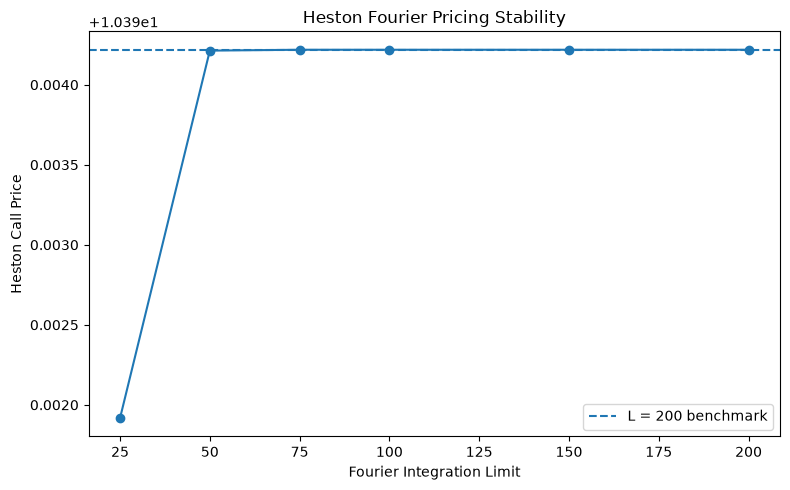

In [6]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    integration_limits,
    integration_prices,
    marker="o",
)

ax.axhline(
    benchmark_price,
    linestyle="--",
    label="L = 200 benchmark",
)

ax.set_xlabel(
    "Fourier Integration Limit"
)

ax.set_ylabel(
    "Heston Call Price"
)

ax.set_title(
    "Heston Fourier Pricing Stability"
)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "figures"
    / "heston_integration_convergence.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretation

The Heston call price converges rapidly as the Fourier integration limit increases.

At $L=25$, a small truncation effect remains. By $L=50$, the pricing error is already very small, while the prices obtained with $L=75$, $100$, $150$, and $200$ are effectively identical at the reported numerical precision.

The baseline value

$$
C_0 \approx 10.39421855
$$

is therefore numerically stable with respect to the integration domain.

The default choice of an integration limit of 150 is conservative for the parameter configuration examined here.

## 7. Semi-Analytical Pricing versus Monte Carlo

The Fourier-based Heston price is deterministic once the numerical integration parameters are fixed.

Monte Carlo pricing instead approximates

$$
C_0
=
e^{-rT}
\mathbb E^{\mathbb Q}
[
\max(S_T-K,0)
]
$$

using simulated Heston paths:

$$
\hat C_{\mathrm{MC}}
=
e^{-rT}
\frac{1}{N}
\sum_{j=1}^{N}
\max(S_T^{(j)}-K,0).
$$

The Monte Carlo estimator is affected by sampling uncertainty. In addition, the current Heston path simulator uses a discrete Euler approximation and therefore also contains time-discretization error.

Consequently,

$$
\hat C_{\mathrm{MC}}-C_{\mathrm{Fourier}}
=
\text{sampling error}
+
\text{time-discretization error}.
$$

In [7]:
fourier_price = heston_call_price(
    **params,
    integration_limit=150,
)

mc_price, mc_se = (
    heston_monte_carlo_price(
        **params,
        option_type="call",
        n_paths=20_000,
        n_steps=252,
        seed=42,
    )
)

ci_lower = (
    mc_price
    - 1.96 * mc_se
)

ci_upper = (
    mc_price
    + 1.96 * mc_se
)

difference = (
    mc_price
    - fourier_price
)

difference_in_se = (
    difference
    / mc_se
)

comparison_df = pd.DataFrame(
    {
        "Method": [
            "Fourier",
            "Monte Carlo",
        ],
        "Price": [
            fourier_price,
            mc_price,
        ],
    }
)

print(
    "Fourier Price:",
    fourier_price,
)

print(
    "Monte Carlo Price:",
    mc_price,
)

print(
    "MC Standard Error:",
    mc_se,
)

print(
    "95% CI:",
    (
        ci_lower,
        ci_upper,
    ),
)

print(
    "MC - Fourier:",
    difference,
)

print(
    "Difference in SE units:",
    difference_in_se,
)

comparison_df

Fourier Price: 10.39421855231327
Monte Carlo Price: 10.378538439815136
MC Standard Error: 0.0868564224250082
95% CI: (10.20829985186212, 10.548777027768152)
MC - Fourier: -0.01568011249813317
Difference in SE units: -0.1805291083877116


,Method,Price
0,Fourier,10.394219
1,Monte Carlo,10.378538


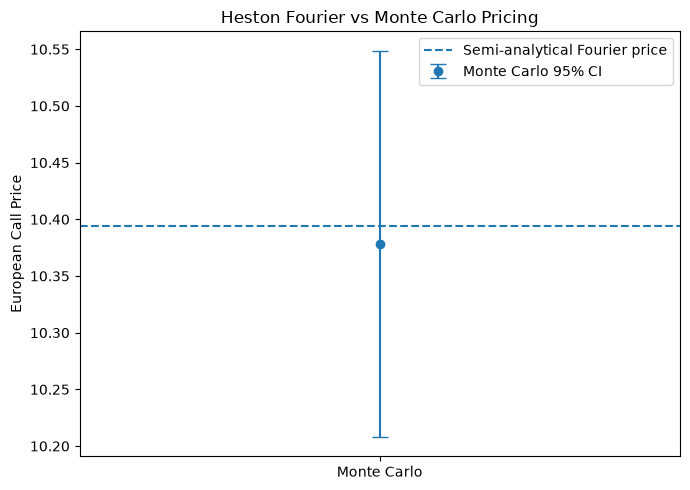

In [8]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.errorbar(
    ["Monte Carlo"],
    [mc_price],
    yerr=[1.96 * mc_se],
    fmt="o",
    capsize=6,
    label="Monte Carlo 95% CI",
)

ax.axhline(
    fourier_price,
    linestyle="--",
    label="Semi-analytical Fourier price",
)

ax.set_ylabel(
    "European Call Price"
)

ax.set_title(
    "Heston Fourier vs Monte Carlo Pricing"
)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "figures"
    / "heston_fourier_vs_mc.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 8. Monte Carlo Time-Discretization Study

The current Heston simulation uses a positivity-truncated Euler approximation for the variance process.

With

$$
\Delta t
=
\frac{T}{N_{\mathrm{steps}}},
$$

increasing the number of time steps produces a finer approximation of the continuous-time Heston dynamics.

However, Monte Carlo estimates also contain sampling noise. Therefore, a single simulation at each grid size cannot cleanly identify time-discretization bias.

To reduce this problem, repeated simulations with different random seeds are performed for each time grid.

### Cross-Validation Result

The semi-analytical Heston price is approximately

$$
10.39422,
$$

while the Monte Carlo estimate is approximately

$$
10.37854.
$$

The Monte Carlo standard error is approximately $0.08686$, giving a 95% sampling interval of approximately

$$
[10.2083,\ 10.5488].
$$

The Fourier benchmark lies comfortably inside this interval.

The difference between the two estimates is only about $0.18$ Monte Carlo standard errors. Hence, no meaningful inconsistency is detected between the two independent pricing approaches.

This provides an important cross-validation of the semi-analytical implementation.

In [9]:
step_values = [
    63,
    126,
    252,
    504,
    1008,
]

seeds = range(10)

n_paths = 10_000

results = []

for n_steps in step_values:

    prices = []
    reported_ses = []

    for seed in seeds:

        price, se = (
            heston_monte_carlo_price(
                **params,
                option_type="call",
                n_paths=n_paths,
                n_steps=n_steps,
                seed=seed,
            )
        )

        prices.append(
            price
        )

        reported_ses.append(
            se
        )

    prices = np.asarray(
        prices
    )

    reported_ses = np.asarray(
        reported_ses
    )

    mean_price = (
        np.mean(prices)
    )

    bias = (
        mean_price
        - fourier_price
    )

    empirical_std = np.std(
        prices,
        ddof=1,
    )

    mean_reported_se = np.mean(
        reported_ses
    )

    rmse = np.sqrt(
        np.mean(
            (
                prices
                - fourier_price
            ) ** 2
        )
    )

    results.append(
        {
            "Steps": n_steps,
            "Mean Price": mean_price,
            "Bias": bias,
            "Empirical Std":
                empirical_std,
            "Mean Reported SE":
                mean_reported_se,
            "RMSE": rmse,
        }
    )

mc_grid_df = pd.DataFrame(
    results
)

mc_grid_df

,Steps,Mean Price,Bias,Empirical Std,Mean Reported SE,RMSE
0,63,10.399236,0.005017,0.115875,0.122536,0.110043
1,126,10.362942,-0.031276,0.166887,0.122307,0.161382
2,252,10.447696,0.053477,0.139348,0.122907,0.142604
3,504,10.450706,0.056488,0.098807,0.122913,0.109441
4,1008,10.442624,0.048405,0.108902,0.122534,0.114091


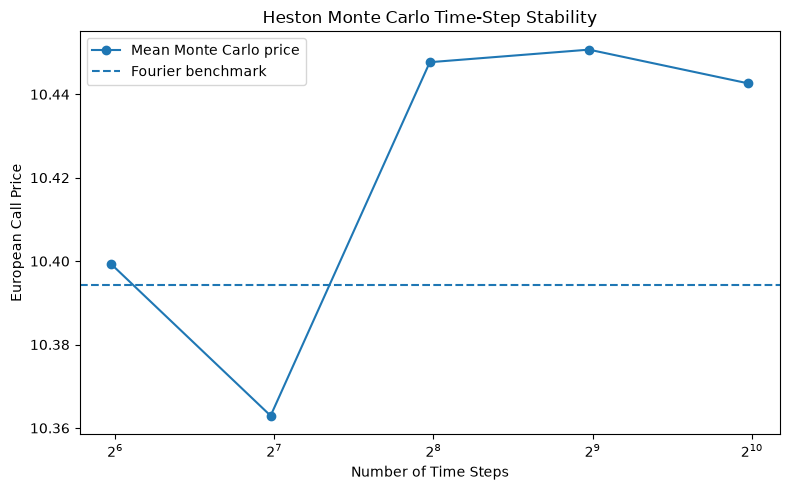

In [10]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    mc_grid_df["Steps"],
    mc_grid_df["Mean Price"],
    marker="o",
    label="Mean Monte Carlo price",
)

ax.axhline(
    fourier_price,
    linestyle="--",
    label="Fourier benchmark",
)

ax.set_xscale(
    "log",
    base=2,
)

ax.set_xlabel(
    "Number of Time Steps"
)

ax.set_ylabel(
    "European Call Price"
)

ax.set_title(
    "Heston Monte Carlo Time-Step Stability"
)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "figures"
    / "heston_mc_timestep_stability.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretation

The repeated Monte Carlo estimates do not display a clear monotonic bias as the time grid is refined from 63 to 1008 steps.

The observed biases relative to the Fourier benchmark remain small compared with the Monte Carlo sampling variability. The typical reported standard error is around 0.12, while the observed mean pricing biases are generally below approximately 0.06.

Therefore, at the current simulation precision, sampling uncertainty dominates the remaining detectable time-discretization effect.

This result should not be interpreted as evidence that Euler discretization has no error. Instead, it indicates that substantially more simulation effort or a variance-reduced paired experiment would be required to estimate the weak discretization bias precisely.

## 9. Heston-Generated Implied Volatility Skew

Black-Scholes assumes a single constant volatility parameter. Under this assumption, options with different strikes should be consistent with the same volatility.

The Heston model instead generates option prices from stochastic variance dynamics. These prices can be converted back into Black-Scholes implied volatilities by solving

$$
V_{\mathrm{BS}}
\left(
\sigma_{\mathrm{imp}}
\right)
=
V_{\mathrm{Heston}}.
$$

If the resulting implied volatility varies across strikes, then the stochastic-volatility model has generated a volatility skew even though no strike-dependent volatility was inserted directly into the model.

This provides the connection between the stochastic dynamics studied previously and the implied-volatility diagnostics developed in the Black-Scholes analysis.

In [11]:
strikes = np.arange(
    70,
    135,
    5,
)

heston_prices = []
heston_implied_vols = []

for strike in strikes:

    price = heston_call_price(
        S0=params["S0"],
        K=float(strike),
        T=params["T"],
        r=params["r"],
        v0=params["v0"],
        kappa=params["kappa"],
        theta=params["theta"],
        xi=params["xi"],
        rho=params["rho"],
        integration_limit=150,
    )

    iv = implied_volatility(
        market_price=price,
        S=params["S0"],
        K=float(strike),
        T=params["T"],
        r=params["r"],
        option_type="call",
    )

    heston_prices.append(
        price
    )

    heston_implied_vols.append(
        iv
    )

heston_skew_df = pd.DataFrame(
    {
        "Strike": strikes,
        "Heston Call Price":
            heston_prices,
        "Implied Volatility":
            heston_implied_vols,
    }
)

heston_skew_df[
    "Log Moneyness"
] = np.log(
    heston_skew_df["Strike"]
    / params["S0"]
)

heston_skew_df

,Strike,Heston Call Price,Implied Volatility,Log Moneyness
0,70,33.827995,0.246632,-0.356675
1,75,29.361206,0.237990,-0.287682
2,80,25.044557,0.229614,-0.223144
3,85,20.929728,0.221480,-0.162519
4,90,17.075310,0.213579,-0.105361
5,95,13.543400,0.205912,-0.051293
6,100,10.394219,0.198498,0.000000
7,105,7.678783,0.191366,0.048790
8,110,5.430339,0.184566,0.095310
9,115,3.656199,0.178157,0.139762


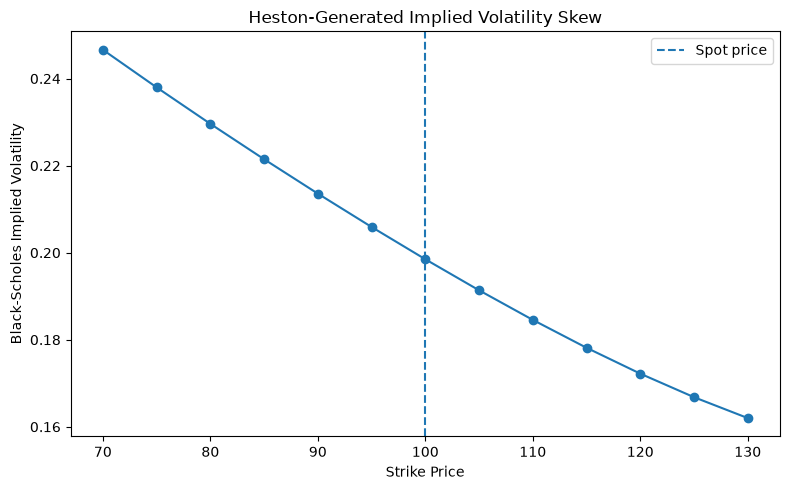

In [12]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    heston_skew_df["Strike"],
    heston_skew_df[
        "Implied Volatility"
    ],
    marker="o",
)

ax.axvline(
    params["S0"],
    linestyle="--",
    label="Spot price",
)

ax.set_xlabel(
    "Strike Price"
)

ax.set_ylabel(
    "Black-Scholes Implied Volatility"
)

ax.set_title(
    "Heston-Generated Implied Volatility Skew"
)

ax.legend()

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "heston_implied_vol_skew.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretation

The implied volatilities recovered from Heston option prices are clearly non-constant across strikes.

For the baseline parameter configuration, implied volatility decreases as the strike increases, producing a downward volatility skew.

This is an important distinction from the constant-volatility Black-Scholes model. No strike-dependent volatility parameter was inserted into the Heston model. Instead, the skew emerges endogenously from the stochastic-variance dynamics and the interaction between stock-price and variance shocks.

The result therefore links three stages of the project:

1. Black-Scholes implied-volatility diagnostics reveal that a single constant volatility is insufficient to describe a non-flat option surface.
2. The Heston model introduces stochastic variance and correlated stock-variance shocks.
3. Heston option prices generate a non-flat Black-Scholes implied-volatility curve.

This establishes the mechanism through which a stochastic-volatility model can potentially address the volatility-skew limitation of Black-Scholes.

## 10. Effect of Stock-Variance Correlation on Implied Volatility

The Heston parameter $\rho$ controls the correlation between stock-price shocks and variance shocks.

A negative value means that negative stock-price shocks tend to be associated with positive variance shocks.

The following experiment holds all other parameters fixed while varying $\rho$ to examine how stock-variance correlation affects the implied-volatility curve.

In [13]:
rho_values = [
    0.0,
    -0.4,
    -0.7,
    -0.9,
]

rho_strikes = np.arange(
    80,
    125,
    5,
)

rho_results = []

for rho_value in rho_values:

    for strike in rho_strikes:

        price = heston_call_price(
            S0=params["S0"],
            K=float(strike),
            T=params["T"],
            r=params["r"],
            v0=params["v0"],
            kappa=params["kappa"],
            theta=params["theta"],
            xi=params["xi"],
            rho=rho_value,
            integration_limit=150,
        )

        iv = implied_volatility(
            market_price=price,
            S=params["S0"],
            K=float(strike),
            T=params["T"],
            r=params["r"],
            option_type="call",
        )

        rho_results.append(
            {
                "rho": rho_value,
                "Strike": strike,
                "Implied Volatility": iv,
            }
        )

rho_df = pd.DataFrame(
    rho_results
)

rho_df.head()

,rho,Strike,Implied Volatility
0,0.0,80,0.203902
1,0.0,85,0.200636
2,0.0,90,0.198111
3,0.0,95,0.196339
4,0.0,100,0.195308


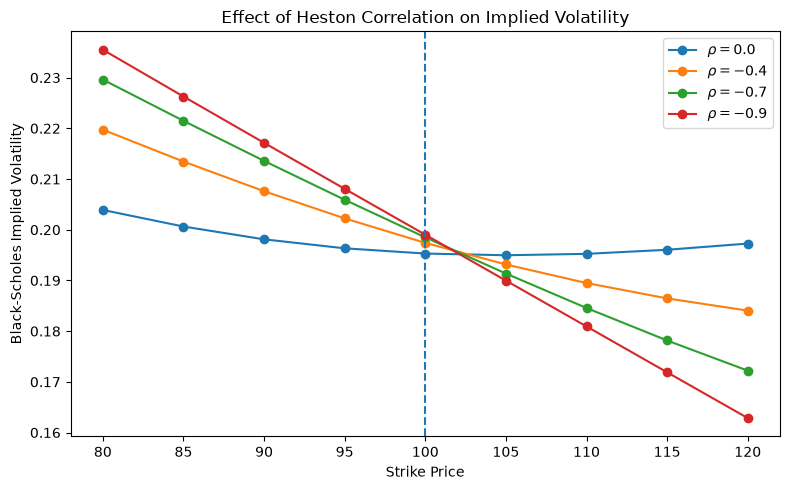

In [14]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

for rho_value in rho_values:

    subset = rho_df[
        rho_df["rho"]
        == rho_value
    ]

    ax.plot(
        subset["Strike"],
        subset[
            "Implied Volatility"
        ],
        marker="o",
        label=fr"$\rho={rho_value}$",
    )

ax.axvline(
    params["S0"],
    linestyle="--",
)

ax.set_xlabel(
    "Strike Price"
)

ax.set_ylabel(
    "Black-Scholes Implied Volatility"
)

ax.set_title(
    "Effect of Heston Correlation on Implied Volatility"
)

ax.legend()

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "heston_rho_iv_effect.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretation of $\rho$

The implied-volatility curves become progressively more asymmetric as the stock-variance correlation becomes more negative.

When $\rho$ is close to zero, the implied-volatility curve is comparatively flat. Under the parameter configurations examined here, increasingly negative values of $\rho$ generate a stronger downward volatility skew.

This result is economically consistent with the leverage-type mechanism observed in the Heston return simulations: negative stock shocks are more strongly associated with positive variance shocks when $\rho$ is negative.

Thus, $\rho$ plays an important role in controlling the asymmetry of the Heston-implied volatility curve.

## 11. Effect of Volatility of Variance

The parameter $\xi$ represents volatility of variance, often referred to as vol-of-vol.

Higher values of $\xi$ allow the instantaneous variance process to fluctuate more strongly around its long-run level.

The following experiment varies $\xi$ while keeping the remaining Heston parameters fixed in order to investigate its effect on the implied-volatility curve.

In [15]:
xi_values = [
    0.10,
    0.30,
    0.60,
]

xi_strikes = np.arange(
    80,
    125,
    5,
)

xi_results = []

for xi_value in xi_values:

    for strike in xi_strikes:

        price = heston_call_price(
            S0=params["S0"],
            K=float(strike),
            T=params["T"],
            r=params["r"],
            v0=params["v0"],
            kappa=params["kappa"],
            theta=params["theta"],
            xi=xi_value,
            rho=params["rho"],
            integration_limit=150,
        )

        iv = implied_volatility(
            market_price=price,
            S=params["S0"],
            K=float(strike),
            T=params["T"],
            r=params["r"],
            option_type="call",
        )

        xi_results.append(
            {
                "xi": xi_value,
                "Strike": strike,
                "Implied Volatility": iv,
            }
        )

xi_df = pd.DataFrame(
    xi_results
)

xi_df.head()

,xi,Strike,Implied Volatility
0,0.1,80,0.211708
1,0.1,85,0.208775
2,0.1,90,0.205989
3,0.1,95,0.203336
4,0.1,100,0.200807


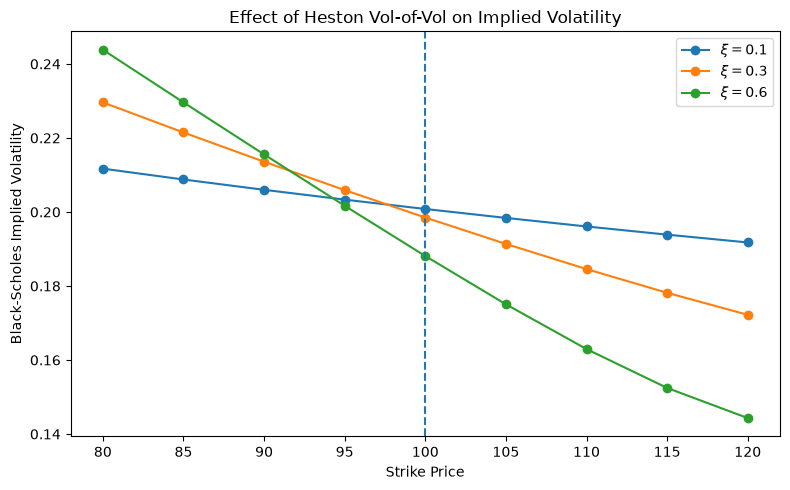

In [16]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

for xi_value in xi_values:

    subset = xi_df[
        xi_df["xi"]
        == xi_value
    ]

    ax.plot(
        subset["Strike"],
        subset[
            "Implied Volatility"
        ],
        marker="o",
        label=fr"$\xi={xi_value}$",
    )

ax.axvline(
    params["S0"],
    linestyle="--",
)

ax.set_xlabel(
    "Strike Price"
)

ax.set_ylabel(
    "Black-Scholes Implied Volatility"
)

ax.set_title(
    "Effect of Heston Vol-of-Vol on Implied Volatility"
)

ax.legend()

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "heston_xi_iv_effect.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Numerical and Model Note

The high-vol-of-vol case $\xi=0.60$ does not satisfy the Feller sufficient condition

$$
2\kappa\theta>\xi^2
$$

under the current values of $\kappa$ and $\theta$.

Failure of the Feller condition does not by itself invalidate the Heston model or the semi-analytical pricing formula. Rather, it means that strict positivity of the continuous-time variance process is no longer guaranteed by this sufficient condition.

The high-$\xi$ case is retained here as a sensitivity experiment rather than as a preferred calibration parameter set.

### Interpretation of $\xi$

Under the parameter configurations examined here, increasing vol-of-vol produces a more pronounced variation in implied volatility across strikes.

The low-$\xi$ configuration generates a comparatively mild volatility skew, while larger values of $\xi$ amplify differences between low-strike and high-strike implied volatilities.

Therefore, $\xi$ influences the strength and curvature of the implied-volatility structure, while $\rho$ plays an especially important role in determining its asymmetry.

The two parameters should not be interpreted independently in calibration, since different combinations of $\rho$ and $\xi$ may produce similar option-price patterns.

## 12. Heston Implied Volatility Across Maturities

Calibration to market option data typically involves options across both strikes and maturities.

To prepare for the calibration analysis, Heston prices are generated for several maturities and converted into Black-Scholes implied volatilities.

This illustrates that the Heston model generates an implied-volatility structure over both strike and maturity rather than only a single volatility-skew curve.

In [17]:
surface_strikes = np.arange(
    80,
    125,
    5,
)

maturities = [
    0.25,
    0.50,
    1.00,
    2.00,
]

surface_results = []

for maturity in maturities:

    for strike in surface_strikes:

        price = heston_call_price(
            S0=params["S0"],
            K=float(strike),
            T=maturity,
            r=params["r"],
            v0=params["v0"],
            kappa=params["kappa"],
            theta=params["theta"],
            xi=params["xi"],
            rho=params["rho"],
            integration_limit=150,
        )

        iv = implied_volatility(
            market_price=price,
            S=params["S0"],
            K=float(strike),
            T=maturity,
            r=params["r"],
            option_type="call",
        )

        surface_results.append(
            {
                "Maturity": maturity,
                "Strike": strike,
                "Implied Volatility": iv,
            }
        )

heston_surface_df = pd.DataFrame(
    surface_results
)

heston_surface_df.head()

,Maturity,Strike,Implied Volatility
0,0.25,80,0.244043
1,0.25,85,0.232709
2,0.25,90,0.221357
3,0.25,95,0.209967
4,0.25,100,0.198578


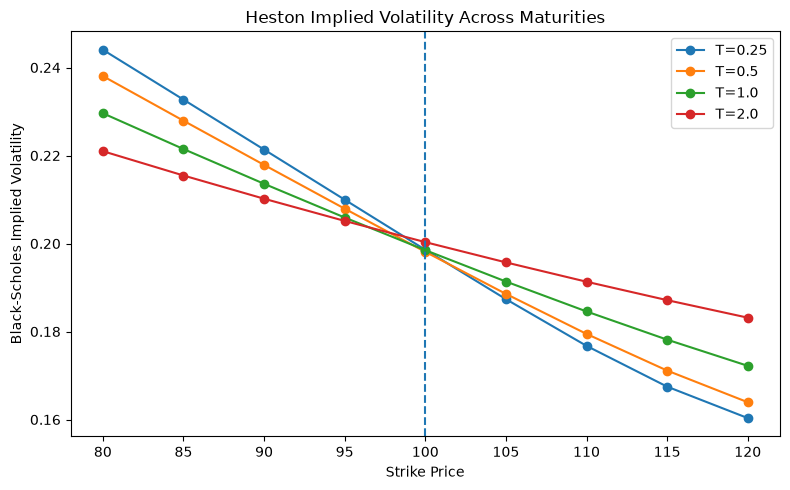

In [18]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

for maturity in maturities:

    subset = heston_surface_df[
        heston_surface_df[
            "Maturity"
        ]
        == maturity
    ]

    ax.plot(
        subset["Strike"],
        subset[
            "Implied Volatility"
        ],
        marker="o",
        label=f"T={maturity}",
    )

ax.axvline(
    params["S0"],
    linestyle="--",
)

ax.set_xlabel(
    "Strike Price"
)

ax.set_ylabel(
    "Black-Scholes Implied Volatility"
)

ax.set_title(
    "Heston Implied Volatility Across Maturities"
)

ax.legend()

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "heston_iv_maturities.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 13. Conclusion

This notebook developed and validated a semi-analytical European option pricing engine under the Heston stochastic-volatility model.

Several layers of numerical validation were performed.

First, the characteristic-function implementation satisfied the identities

$$
\phi(0)=1
$$

and

$$
\phi(-i)=S_0e^{rT}.
$$

Second, the resulting call and put prices satisfied standard no-arbitrage conditions and put-call parity.

Third, the Fourier pricing result was numerically stable with respect to the integration limit. For the baseline configuration, the call price converged to approximately

$$
10.39421855.
$$

Fourth, an independent Heston Monte Carlo estimate was statistically consistent with the semi-analytical benchmark. The difference was small relative to Monte Carlo sampling uncertainty.

A repeated time-step experiment showed that no clear monotonic Euler discretization pattern could be detected at the current simulation precision. The remaining time-discretization effect appears small relative to Monte Carlo sampling noise.

Finally, converting Heston option prices into Black-Scholes implied volatilities generated a non-flat volatility structure. Negative stock-variance correlation produced stronger downward skew under the parameter configurations examined, while higher vol-of-vol amplified variation across strikes.

These results connect the stochastic-volatility dynamics studied previously with the implied-volatility diagnostics developed under Black-Scholes.

The next step is model calibration: rather than choosing Heston parameters and generating option prices, the problem will be reversed. Synthetic or market option prices will be observed, and the Heston parameters will be estimated by minimizing pricing errors across strikes and maturities.